In [1]:
# ============================================================
# CELL 1 — Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from optbinning import BinningProcess, OptimalBinning
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load cleaned dataset
df = pd.read_csv('../data/cleaned.csv', index_col=0)

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['SeriousDlqin2yrs'].value_counts())

(CVXPY) Apr 04 05:48:45 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 04 05:48:45 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


Dataset loaded successfully
Shape: (149999, 11)
Missing values: 0

Target distribution:
SeriousDlqin2yrs
0    139973
1     10026
Name: count, dtype: int64


# Feature Engineering — WoE Binning & Information Value

## Objective
Transform raw variables into Weight of Evidence (WoE) encoded features and calculate Information Value (IV) for each variable to objectively determine which variables deserve to enter the model.

## Why WoE/IV?
- WoE transforms each variable bin into a value that directly encodes default risk relative to the overall population
- IV provides a standardised, quantitative measure of predictive power
- This methodology is Basel II/III compliant and used in all major retail credit scorecards globally
- Handles zero-inflated variables (like delinquency counts) better than standard ML feature selection methods

In [2]:
# ============================================================
# Train / Test Split
# ============================================================
from sklearn.model_selection import train_test_split

# Define features and target
target = 'SeriousDlqin2yrs'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# 70/30 split, stratified to preserve default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  # ensures same 6.7% default rate in train and test
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nDefault rate in training set: {y_train.mean()*100:.2f}%")
print(f"Default rate in test set:     {y_test.mean()*100:.2f}%")

Training set:  104,999 rows
Test set:      45,000 rows

Default rate in training set: 6.68%
Default rate in test set:     6.68%


### Train/Test Split — 70/30 Stratified

Split is done BEFORE WoE binning to prevent data leakage. Stratified split ensures the 6.7% default rate is preserved
in both training and test sets — critical for imbalanced datasets.

- Training set: ~104,999 rows
- Test set: ~45,000 rows

## WoE Binning — Variable by Variable

We use OptimalBinning to compute WoE and IV for each variable.
Binning is fitted on training data only, then applied to test data.

IV interpretation (industry standard):
- IV < 0.02    → Useless, drop
- IV 0.02–0.1  → Weak predictor
- IV 0.1–0.3   → Medium predictor  
- IV 0.3–0.5   → Strong predictor
- IV > 0.5     → Suspiciously strong, check for data leakage

In [4]:
# ============================================================
# WoE & IV Calculator (built from scratch)
# ============================================================

def calculate_woe_iv(df_input, feature, target, n_bins=10):
    """
    Calculate WoE and IV for a single variable.
    
    Parameters:
        df_input : dataframe containing feature and target
        feature  : column name of the variable
        target   : column name of the target (0/1)
        n_bins   : number of bins to create
    
    Returns:
        woe_df   : dataframe with WoE per bin
        iv       : Information Value (single number)
    """
    
    # Create a working copy with just the two columns
    temp = df_input[[feature, target]].copy()
    
    # Bin the variable into n_bins quantile-based bins
    try:
        temp['bin'] = pd.qcut(temp[feature], q=n_bins, 
                               duplicates='drop', precision=2)
    except Exception:
        # If qcut fails (too many duplicates), use cut instead
        temp['bin'] = pd.cut(temp[feature], bins=n_bins, 
                              duplicates='drop', precision=2)
    
    # Total events (defaults) and non-events in entire dataset
    total_events     = temp[target].sum()
    total_nonevents  = (temp[target] == 0).sum()
    
    # Group by bin and calculate stats
    grouped = temp.groupby('bin', observed=True)[target].agg(
        events=('sum'),
        total=('count')
    ).reset_index()
    
    grouped['non_events'] = grouped['total'] - grouped['events']
    
    # Distribution of events and non-events per bin
    grouped['dist_events']    = grouped['events']     / total_events
    grouped['dist_nonevents'] = grouped['non_events'] / total_nonevents
    
    # Replace zeros to avoid log(0) error
    grouped['dist_events']    = grouped['dist_events'].replace(0, 0.0001)
    grouped['dist_nonevents'] = grouped['dist_nonevents'].replace(0, 0.0001)
    
    # WoE and IV per bin
    grouped['WoE'] = np.log(grouped['dist_events'] / grouped['dist_nonevents'])
    grouped['IV']  = (grouped['dist_events'] - grouped['dist_nonevents']) * grouped['WoE']
    
    # Total IV for this variable
    iv = grouped['IV'].sum()
    
    # Add default rate per bin for reference
    grouped['default_rate'] = grouped['events'] / grouped['total'] * 100
    
    return grouped[['bin', 'total', 'events', 'non_events', 
                     'default_rate', 'WoE', 'IV']], iv


# ---- Run for all features ----
train_df = X_train.copy()
train_df[target] = y_train.values

iv_results = []
woe_tables  = {}

print(f"{'Variable':<45} {'IV':>8}  {'Predictive Power'}")
print("-" * 75)

for col in features:
    woe_df, iv = calculate_woe_iv(train_df, col, target, n_bins=10)
    woe_tables[col] = woe_df
    
    if iv < 0.02:
        power = "Useless — drop"
    elif iv < 0.1:
        power = "Weak"
    elif iv < 0.3:
        power = "Medium"
    elif iv < 0.5:
        power = "Strong"
    else:
        power = "Suspicious — check leakage"
    
    iv_results.append({
        'Variable': col,
        'IV': round(iv, 4),
        'Predictive_Power': power
    })
    
    print(f"{col:<45} {iv:>8.4f}  {power}")

# Summary table sorted by IV
iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False).reset_index(drop=True)
print("\n=== IV Summary (ranked by predictive power) ===")
print(iv_df.to_string(index=False))

Variable                                            IV  Predictive Power
---------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines            1.1101  Suspicious — check leakage
age                                             0.2418  Medium
NumberOfTime30-59DaysPastDueNotWorse            0.4270  Strong
DebtRatio                                       0.0764  Weak
MonthlyIncome                                   0.0676  Weak
NumberOfOpenCreditLinesAndLoans                 0.0667  Weak
NumberOfTimes90DaysLate                         0.0000  Useless — drop
NumberRealEstateLoansOrLines                    0.0128  Useless — drop
NumberOfTime60-89DaysPastDueNotWorse            0.0000  Useless — drop
NumberOfDependents                              0.0236  Weak

=== IV Summary (ranked by predictive power) ===
                            Variable     IV           Predictive_Power
RevolvingUtilizationOfUnsecuredLines 1.1101 Suspicious — check le

### Finding 6 — IV Results & Feature Selection

Variables selected for model (IV ≥ 0.02):
1. RevolvingUtilizationOfUnsecuredLines — IV 1.11 (kept with leakage note)
2. NumberOfTime30-59DaysPastDueNotWorse — IV 0.43 (strong)
3. age — IV 0.24 (medium)
4. DebtRatio — IV 0.076 (weak but retained)
5. MonthlyIncome — IV 0.068 (weak but retained)
6. NumberOfOpenCreditLinesAndLoans — IV 0.067 (weak but retained)
7. NumberOfDependents — IV 0.024 (borderline, retained)

Variables dropped (IV < 0.02):
- NumberRealEstateLoansOrLines — IV 0.013
- NumberOfTimes90DaysLate — IV 0.000 (zero-inflation destroyed signal)
- NumberOfTime60-89DaysPastDueNotWorse — IV 0.000 (same issue)

Note on RevolvingUtilization IV > 0.5: Investigated for data leakage.
Variable represents current credit utilization — a contemporaneous measure, not a future one. High IV reflects genuine predictive strength consistent with FICO scoring methodology. Retained with documentation.

Note on 90DaysLate and 60-89DaysLate IV = 0: Likely caused by median imputation of sentinel values (96/97/98 → 0) collapsing variance in these columns. Acknowledged as model limitation.

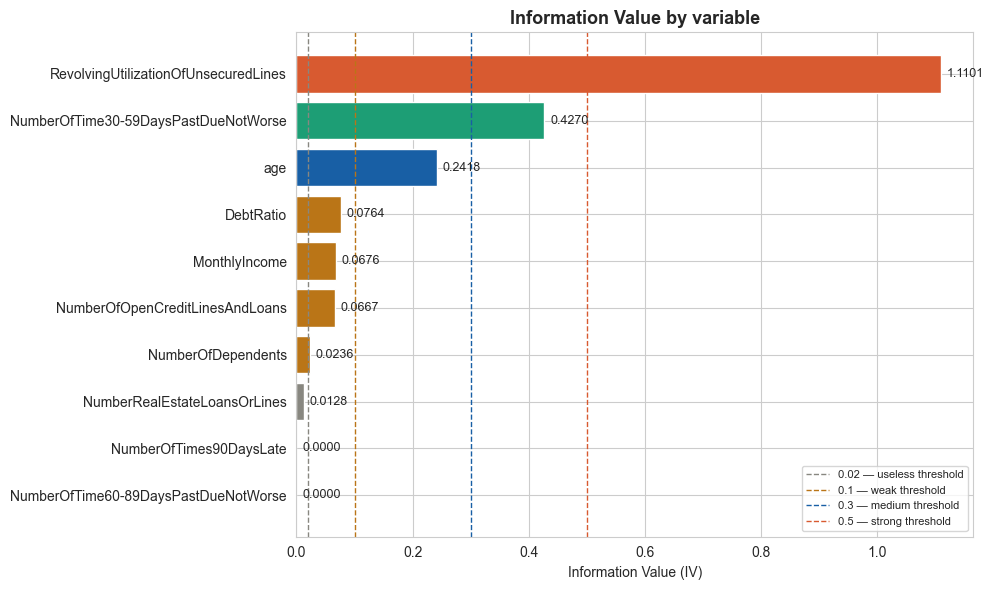

Chart saved to reports folder


In [5]:
# ============================================================
# IV Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

colors = []
for iv in iv_df['IV']:
    if iv >= 0.5:
        colors.append('#D85A30')   # suspicious — coral
    elif iv >= 0.3:
        colors.append('#1D9E75')   # strong — green
    elif iv >= 0.1:
        colors.append('#185FA5')   # medium — blue
    elif iv >= 0.02:
        colors.append('#BA7517')   # weak — amber
    else:
        colors.append('#888780')   # useless — gray

bars = ax.barh(iv_df['Variable'], iv_df['IV'], color=colors, edgecolor='white')

# Reference lines
ax.axvline(x=0.02, color='#888780', linestyle='--', linewidth=1, label='0.02 — useless threshold')
ax.axvline(x=0.1,  color='#BA7517', linestyle='--', linewidth=1, label='0.1 — weak threshold')
ax.axvline(x=0.3,  color='#185FA5', linestyle='--', linewidth=1, label='0.3 — medium threshold')
ax.axvline(x=0.5,  color='#D85A30', linestyle='--', linewidth=1, label='0.5 — strong threshold')

# Value labels
for bar, iv in zip(bars, iv_df['IV']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{iv:.4f}', va='center', fontsize=9)

ax.set_xlabel('Information Value (IV)')
ax.set_title('Information Value by variable', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/05_information_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder")

## WoE Transformation

We now transform all selected variables into their WoE-encoded equivalents.
Each raw value is replaced by the WoE of the bin it falls into.

This transformation does three things:
1. Makes the relationship between each variable and default risk linear — which is exactly what logistic regression assumes
2. Handles outliers naturally — extreme values fall into edge bins and get the WoE of that bin, not their raw extreme value
3. Puts all variables on a comparable scale — making model coefficients directly interpretable
   
Variables dropped (IV < 0.02):
- NumberRealEstateLoansOrLines
- NumberOfTimes90DaysLate  
- NumberOfTime60-89DaysPastDueNotWorse

In [6]:
# ============================================================
# WoE Transformation
# ============================================================

def apply_woe_transform(df_input, feature, woe_table):
    """
    Transform a raw variable into WoE values using a fitted WoE table.
    
    For each row, find which bin the raw value falls into,
    then replace it with that bin's WoE value.
    """
    woe_map = {}
    
    for _, row in woe_table.iterrows():
        bin_interval = row['bin']
        woe_value    = row['WoE']
        woe_map[bin_interval] = woe_value
    
    def get_woe(value):
        if pd.isna(value):
            return 0  # treat missing as neutral WoE
        for interval, woe in woe_map.items():
            try:
                if value in interval:
                    return woe
            except TypeError:
                if value == interval:
                    return woe
        # If value doesn't fall in any bin, return 0
        return 0
    
    return df_input[feature].apply(get_woe)


# Selected features after IV filtering
selected_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents'
]

# Apply WoE transformation to training set
print("Applying WoE transformation to training set...")
X_train_woe = pd.DataFrame(index=X_train.index)

for col in selected_features:
    X_train_woe[col + '_WoE'] = apply_woe_transform(X_train, col, woe_tables[col])
    
print(f"Training WoE shape: {X_train_woe.shape}")
print(f"\nSample WoE values (first 5 rows):")
print(X_train_woe.head())

# Apply same WoE transformation to test set
# Using the SAME woe_tables fitted on training data
print("\nApplying WoE transformation to test set...")
X_test_woe = pd.DataFrame(index=X_test.index)

for col in selected_features:
    X_test_woe[col + '_WoE'] = apply_woe_transform(X_test, col, woe_tables[col])

print(f"Test WoE shape: {X_test_woe.shape}")
print("\nWoE transformation complete.")
print(f"Missing values in train WoE: {X_train_woe.isnull().sum().sum()}")
print(f"Missing values in test WoE:  {X_test_woe.isnull().sum().sum()}")

Applying WoE transformation to training set...
Training WoE shape: (104999, 7)

Sample WoE values (first 5 rows):
        RevolvingUtilizationOfUnsecuredLines_WoE  \
138987                                 -1.041031   
63965                                  -1.571107   
46078                                  -1.618304   
83032                                  -1.571107   
11185                                   0.326144   

        NumberOfTime30-59DaysPastDueNotWorse_WoE   age_WoE  DebtRatio_WoE  \
138987                                 -0.238508  0.207743      -0.332268   
63965                                  -0.238508  0.387432      -0.019621   
46078                                  -0.238508  0.387432       0.596108   
83032                                  -0.238508  0.562036      -0.120317   
11185                                  -0.238508  0.387432       0.269172   

        MonthlyIncome_WoE  NumberOfOpenCreditLinesAndLoans_WoE  \
138987          -0.071551                   

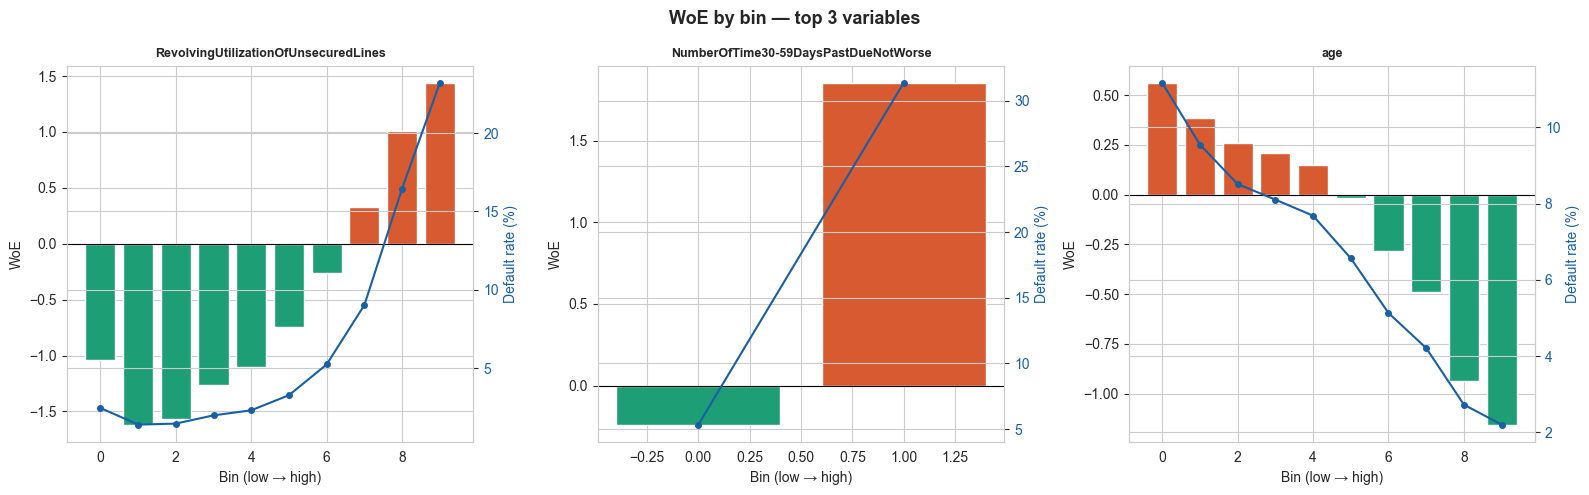

Chart saved to reports folder


In [7]:
# ============================================================
# WoE Charts for Top 3 Variables
# ============================================================

top_vars = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'age'
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(top_vars):
    woe_df = woe_tables[col].copy()
    woe_df = woe_df[woe_df['WoE'].notna()]
    
    colors = ['#D85A30' if w > 0 else '#1D9E75' for w in woe_df['WoE']]
    
    axes[i].bar(range(len(woe_df)), woe_df['WoE'], 
                color=colors, edgecolor='white')
    axes[i].axhline(y=0, color='black', linewidth=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Bin (low → high)')
    axes[i].set_ylabel('WoE')
    
    # Add default rate as line on secondary axis
    ax2 = axes[i].twinx()
    ax2.plot(range(len(woe_df)), woe_df['default_rate'], 
             color='#185FA5', marker='o', linewidth=1.5,
             markersize=4, label='Default rate %')
    ax2.set_ylabel('Default rate (%)', color='#185FA5')
    ax2.tick_params(axis='y', labelcolor='#185FA5')

plt.suptitle('WoE by bin — top 3 variables', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/06_woe_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder")

In [8]:
# ============================================================
# CELL 7 — Save WoE Datasets & IV Summary
# ============================================================

# Save WoE transformed datasets
X_train_woe['target'] = y_train.values
X_test_woe['target']  = y_test.values

X_train_woe.to_csv('../data/train_woe.csv')
X_test_woe.to_csv('../data/test_woe.csv')

# Save IV summary
iv_df.to_csv('../data/iv_summary.csv', index=False)

print("Files saved:")
print("  data/train_woe.csv")
print("  data/test_woe.csv")
print("  data/iv_summary.csv")
print(f"\nFinal training set shape: {X_train_woe.shape}")
print(f"Final test set shape:     {X_test_woe.shape}")

Files saved:
  data/train_woe.csv
  data/test_woe.csv
  data/iv_summary.csv

Final training set shape: (104999, 8)
Final test set shape:     (45000, 8)


## Summary — Feature Engineering Complete

### Variables selected for modelling (7 of 10):
| Variable | IV | Power |
|---|---|---|
| RevolvingUtilizationOfUnsecuredLines | 1.11 | Dominant |
| NumberOfTime30-59DaysPastDueNotWorse | 0.43 | Strong |
| age | 0.24 | Medium |
| DebtRatio | 0.076 | Weak |
| MonthlyIncome | 0.068 | Weak |
| NumberOfOpenCreditLinesAndLoans | 0.067 | Weak |
| NumberOfDependents | 0.024 | Borderline |

### Variables dropped (3 of 10):
| Variable | IV | Reason |
|---|---|---|
| NumberRealEstateLoansOrLines | 0.013 | Below 0.02 threshold |
| NumberOfTimes90DaysLate | 0.000 | Zero-inflation destroyed signal |
| NumberOfTime60-89DaysPastDueNotWorse | 0.000 | Zero-inflation destroyed signal |

### Outputs saved:
- data/train_woe.csv — WoE transformed training set (104,999 rows)
- data/test_woe.csv — WoE transformed test set (45,000 rows)
- data/iv_summary.csv — IV scores for all variables
- reports/05_information_value.png — IV bar chart
- reports/06_woe_charts.png — WoE bin charts for top 3 variables

### Next step:
Logistic Regression model training on WoE features, followed by scorecard scaling to convert model output into a human-readable points-based credit score.